# Feature Detection Algorithms — SIFT, SURF, ORB

Feature detection (in cv): identify distinctive points (keypoints) in an image. These  
-  object detection
-  image matching
-  SLAM (Simultaneous Localization and Mapping)
-  tracking.

## SIFT (Scale-Invariant Feature Transform)

SIFT detects keypoints by identifying extrema in scale-space using Difference of Gaussians (DoG).

*Steps*
- Construct scale-space using Gaussian blur
- Compute Difference of Gaussians
- Detect extrema (keypoints)
- Assign orientation
- Generate descriptor
- 
*Descriptor*
- 128-dimensional vector
- Based on gradient orientation histograms

*Invariance*
- Scale invariant 
- Rotation invariant 
- Illumination partially invariant
  
## SURF (Speeded-Up Robust Features)


SURF improves speed using Hessian matrix approximation and integral images.

*Steps*
- Use integral images for fast computation
- Detect keypoints using Hessian matrix
- Assign orientation
- Compute descriptor using Haar wavelets
*Descriptor*
- Based on Haar wavelet responses
*Invariance*
- Scale invariant 
- Rotation invariant 
- Faster than SIFT

## ORB (Oriented FAST and Rotated BRIEF)
ORB combines FAST keypoint detection and BRIEF descriptor.

*Steps*
- Detect keypoints using FAST
- Assign orientation
- Compute rotated BRIEF descriptor
*Descriptor*
- Binary descriptor (very fast comparison)
*Invariance*
- Rotation invariant
- Scale invariant (partial)
- Very fast
- 
## Comparison
Feature 	            SIFT	SURF	ORB
Speed	                Slow	Medium	Fast
Accuracy	            High	Good	Moderate
Descriptor	      float (128-d)	Float	Binary
Scale Invariance	     Yes	Yes	Partial
Rotation Invariance	     Yes	Yes	Yes

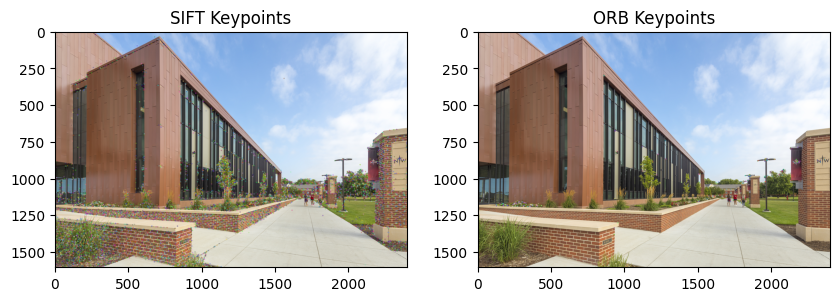

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#SIFT 
sift = cv2.SIFT_create()
kp_sift, des_sift = sift.detectAndCompute(gray, None)
img_sift = cv2.drawKeypoints(img, kp_sift, None)

#  ORB
orb = cv2.ORB_create()
kp_orb, des_orb = orb.detectAndCompute(gray, None)
img_orb = cv2.drawKeypoints(img, kp_orb, None)

#  Display 
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("SIFT Keypoints")
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("ORB Keypoints")
plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))

plt.show()

The output image appears visually similar to the original image, but keypoints are highlighted as small markers. These keypoints represent distinctive regions such as edges and corners. SIFT detects more detailed and dense keypoints, while ORB detects fewer but faster-computed keypoints

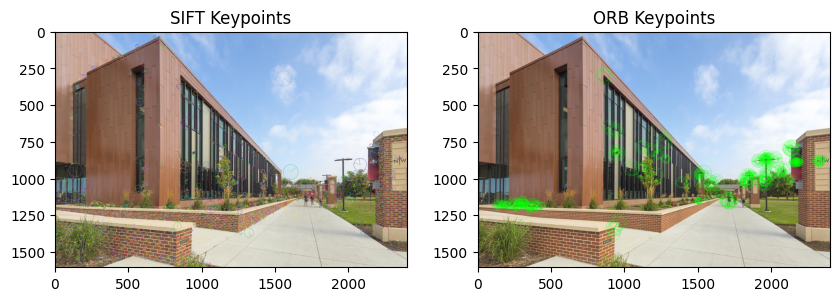

In [5]:
img_sift = cv2.drawKeypoints(
    img, kp_sift, None, 
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_orb = cv2.drawKeypoints(
    img, kp_orb, None, 
    color=(0,255,0), 
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

#  Display 
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("SIFT Keypoints")
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("ORB Keypoints")
plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))

plt.show()